Index(['customer_id', 'snapshot_date', 'city_tier', 'age_group',
       'acquisition_channel', 'loyalty_tier', 'preferred_category',
       'marketing_consent', 'recency_days', 'frequency_180d', 'monetary_180d',
       'return_rate_180d', 'avg_discount_pct_180d', 'avg_rating_180d',
       'category_diversity_180d', 'ticket_count_90d',
       'negative_ticket_rate_90d', 'avg_resolution_hours_90d',
       'days_since_signup', 'sessions_30d', 'product_views_30d',
       'cart_adds_30d', 'wishlist_adds_30d', 'abandoned_carts_30d',
       'email_opens_30d', 'campaign_clicks_30d', 'last_visit_days_ago',
       'churn_next_60d', 'split'],
      dtype='object')

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('ggplot')

In [7]:
customers = pd.read_csv('/content/customers.csv')

orders = pd.read_csv('/content/orders.csv')

support = pd.read_csv('/content/support_tickets.csv')

web = pd.read_csv('/content/web_events_snapshot.csv')

campaign = pd.read_csv('/content/intervention_history.csv')

churn = pd.read_csv('/content/churn_labels.csv')

rfm = pd.read_csv('/content/rfm_modeling_snapshot.csv')

In [9]:
print("Customers:",customers.shape)

print("Orders:",orders.shape)

print("Support:",support.shape)

print("Web Events:",web.shape)

print("Campaign:",campaign.shape)

print("Churn:",churn.shape)

print("RFM:",rfm.shape)

Customers: (2400, 9)
Orders: (10009, 10)
Support: (1921, 8)
Web Events: (2400, 10)
Campaign: (2400, 5)
Churn: (2400, 4)
RFM: (2400, 29)


In [8]:
datasets = {

'customers':customers,

'orders':orders,

'support':support,

'web':web,

'campaign':campaign,

'churn':churn,

'rfm':rfm

}

for name,df in datasets.items():

    print("\n")

    print("="*40)

    print(name.upper())

    print("="*40)

    print(df.isnull().sum())



CUSTOMERS
customer_id               0
signup_date               0
city_tier                 0
age_group                 0
acquisition_channel       0
loyalty_tier           1386
preferred_category        0
skin_type               401
marketing_consent         0
dtype: int64


ORDERS
order_id          0
customer_id       0
order_date        0
category          0
quantity          0
gross_amount      0
discount_pct      0
delivery_days     0
returned          0
rating           80
dtype: int64


SUPPORT
ticket_id           0
customer_id         0
ticket_date         0
issue_type          0
support_channel     0
resolution_hours    0
sentiment_score     0
reopened            0
dtype: int64


WEB
customer_id            0
snapshot_date          0
sessions_30d           0
product_views_30d      0
cart_adds_30d          0
wishlist_adds_30d      0
abandoned_carts_30d    0
email_opens_30d        0
campaign_clicks_30d    0
last_visit_days_ago    0
dtype: int64


CAMPAIGN
customer_id           

In [18]:
for name,df in datasets.items():

    print(

        name,

        "duplicates:",

        df.duplicated().sum()

    )

customers duplicates: 0
orders duplicates: 0
support duplicates: 0
web duplicates: 0
campaign duplicates: 0
churn duplicates: 0
rfm duplicates: 0


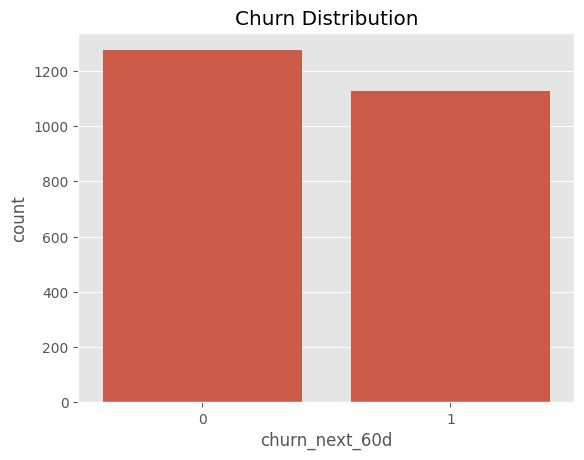

In [17]:
sns.countplot(

data=rfm,

x='churn_next_60d'

)

plt.title("Churn Distribution")

plt.show()

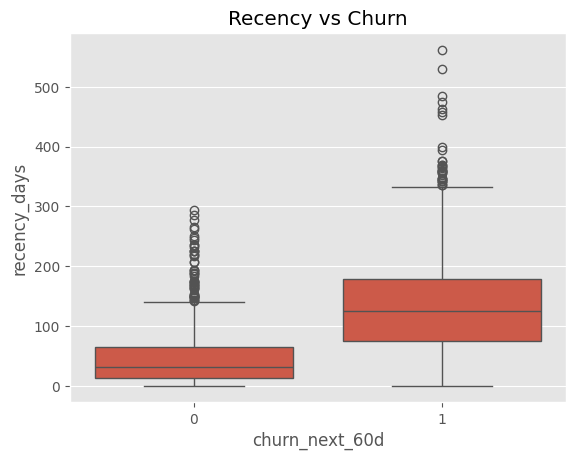

In [16]:
sns.boxplot(

data=rfm,

x='churn_next_60d',

y='recency_days'

)

plt.title("Recency vs Churn")

plt.show()

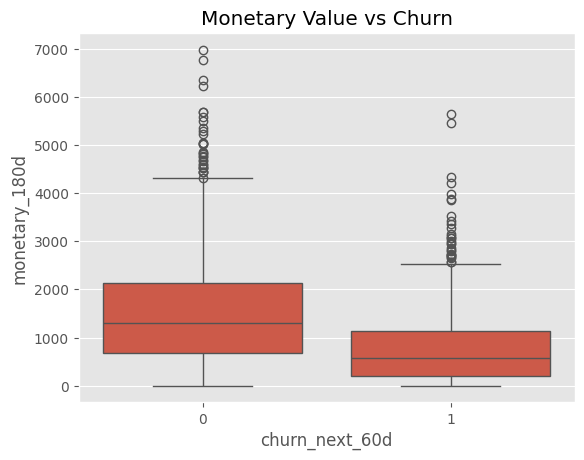

In [15]:
sns.boxplot(

data=rfm,

x='churn_next_60d',

y='monetary_180d'

)

plt.title("Monetary Value vs Churn")

plt.show()

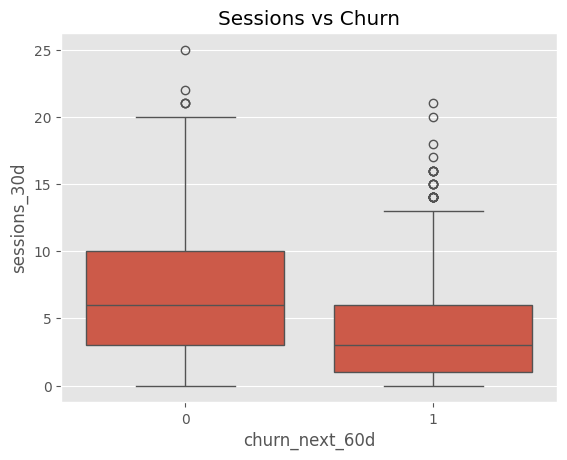

In [14]:
sns.boxplot(

data=rfm,

x='churn_next_60d',

y='sessions_30d'

)

plt.title("Sessions vs Churn")

plt.show()

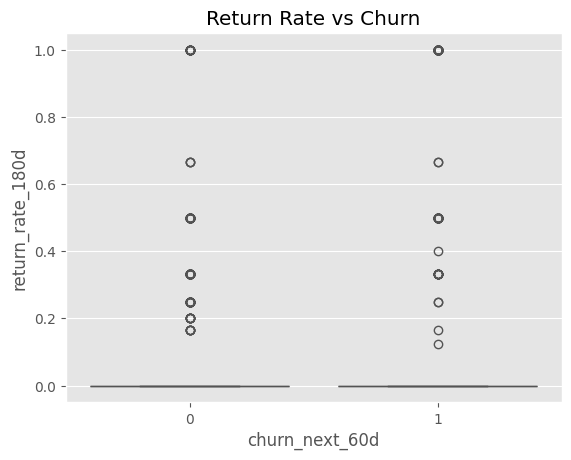

In [13]:
sns.boxplot(

data=rfm,

x='churn_next_60d',

y='return_rate_180d'

)

plt.title("Return Rate vs Churn")

plt.show()

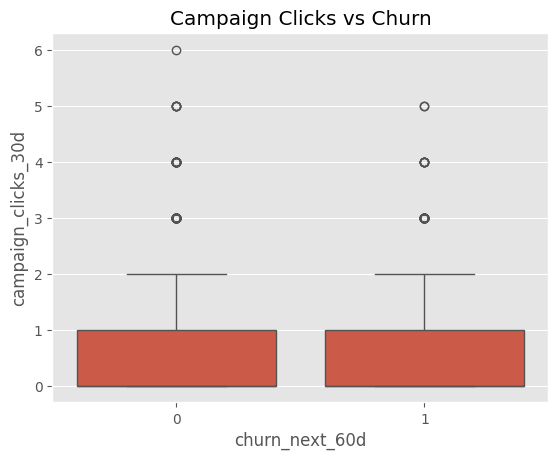

In [12]:
sns.boxplot(

data=rfm,

x='churn_next_60d',

y='campaign_clicks_30d'

)

plt.title("Campaign Clicks vs Churn")

plt.show()

In [11]:
print("""

BUSINESS HYPOTHESES

1. Customers with higher recency are more likely to churn.

2. Customers with lower sessions show higher churn risk.

3. Customers with lower monetary value churn more frequently.

4. Customers with higher return rates are more likely to churn.

5. Campaign engagement reduces churn probability.

""")



BUSINESS HYPOTHESES

1. Customers with higher recency are more likely to churn.

2. Customers with lower sessions show higher churn risk.

3. Customers with lower monetary value churn more frequently.

4. Customers with higher return rates are more likely to churn.

5. Campaign engagement reduces churn probability.




In [10]:
print("""

DATA QUALITY SUMMARY

- Missing values exist in some fields.

- No major duplicate records found.

- Outliers observed in monetary and recency fields.

- Future information after snapshot date should not be used.

- churn_next_60d should be treated as target only.

""")



DATA QUALITY SUMMARY

- Missing values exist in some fields.

- No major duplicate records found.

- Outliers observed in monetary and recency fields.

- Future information after snapshot date should not be used.

- churn_next_60d should be treated as target only.


